# 21SJ-14K EDAレポート2（発注残最適化）

このノートブックは、初心者の方でも追えるように、**考え方 → 計算 → 可視化 → 判断** の順で進めます。

## この分析でやりたいこと
- 欠品を減らして売り逃しを抑える
- 発注残の多いSKUを整理する
- 工場キャパ（月200着）で「どのSKUを優先生産するか」を決める

## 分析の流れ
1. データ読み込みと前処理
2. 需要（売上）を把握
3. 供給不足（発注残）を把握
4. 欠品履歴（在庫ゼロ日数）を把握
5. 優先度スコアを作成
6. 月200着で配分シミュレーション

> 重要: グラフや表は **JANではなく品名中心** で表示します（必要時だけJAN末尾4桁を補助表示）。


In [1]:
# 依存ライブラリの読み込み（不足時は自動インストール）
# ここは環境差でエラーが出やすいので、最初に吸収しておきます。
import importlib
import subprocess
import sys
import warnings
from pathlib import Path

required = ['numpy', 'pandas', 'matplotlib', 'seaborn']
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing.append(pkg)

if missing:
    print('不足パッケージをインストールします:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U', *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = ['Yu Gothic', 'Meiryo', 'MS Gothic', 'DejaVu Sans']

DATA_DIR = Path('.')
print('Python:', sys.executable)
print('作業ディレクトリ:', DATA_DIR.resolve())

Python: c:\Users\t.ouchi\OneDrive\デスクトップ\Github\Kaggle\data\kimono_fabric\.venv\Scripts\python.exe
作業ディレクトリ: C:\Users\t.ouchi\OneDrive\デスクトップ\Github\Kaggle\data\kimono_fabric\21SJ-14K 分析


In [2]:
# 文字コード差を吸収してCSVを読む関数

def read_csv_fallback(path: Path, **kwargs):
    last_error = None
    for enc in ['utf-8-sig', 'cp932']:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except Exception as e:
            last_error = e
    raise last_error

# 今回使う入力ファイル
sales_path = DATA_DIR / '21SJ-14K売上集計.csv'
open_detail_path = DATA_DIR / '21SJ-14K_JAN別_発注残数_発注No連携.csv'
open_jan_path = DATA_DIR / '21SJ-14K_JAN別_発注残数_発注No連携2.csv'
stockout_path = DATA_DIR / '在庫切れ期間一覧_452限定.csv'
stock_ledger_path = DATA_DIR / '整理済み在庫データ_452限定.csv'  # 現在在庫を作る元データ

for pth in [sales_path, open_detail_path, open_jan_path, stockout_path, stock_ledger_path]:
    print(f'{pth.name}:', 'OK' if pth.exists() else 'NOT FOUND')

21SJ-14K売上集計.csv: OK
21SJ-14K_JAN別_発注残数_発注No連携.csv: OK
21SJ-14K_JAN別_発注残数_発注No連携2.csv: OK
在庫切れ期間一覧_452限定.csv: OK
整理済み在庫データ_452限定.csv: OK


In [3]:
# データ読み込み
# ヘッダーなしCSVには列名を明示します。

sales_cols = [
    'year', 'ym', 'sales_date', 'customer_code', 'customer_name',
    'jan', 'item_name', 'model', 'color', 'size', 'pref', 'sales_qty', 'industry'
]
open_detail_cols = [
    'po_no', 'po_date_int', 'po_date', 'vendor_code', 'jan', 'item_name',
    'model', 'color', 'size', 'po_qty', 'recv_qty', 'open_qty',
    'first_recv_int', 'last_recv_int', 'status', 'open_days'
]
open_jan_cols = [
    'jan', 'item_name', 'model', 'color', 'size',
    'po_qty_total', 'recv_qty_total', 'open_qty_total', 'unreceived_qty',
    'open_po_count', 'max_open_days'
]
stockout_cols = ['jan', 'stockout_date', 'restock_date', 'stockout_days']

sales = read_csv_fallback(sales_path, header=None, names=sales_cols)
open_detail = read_csv_fallback(open_detail_path, header=None, names=open_detail_cols)
open_jan = read_csv_fallback(open_jan_path, header=None, names=open_jan_cols)
stockout = read_csv_fallback(stockout_path, header=0)
stockout.columns = stockout_cols

# 現在在庫算出用（取引履歴）
stock_ledger = read_csv_fallback(stock_ledger_path, header=0)
stock_ledger = stock_ledger.rename(columns={
    '商品コード': 'jan',
    '商品名': 'item_name_ledger',
    '入出荷日': 'txn_date',
    '在庫数': 'stock_qty'
})

# 型を整える（ここで整えておくと後続セルが安定します）
sales['sales_date'] = pd.to_datetime(sales['sales_date'].astype(str), format='%Y%m%d', errors='coerce')
sales['sales_qty'] = pd.to_numeric(sales['sales_qty'], errors='coerce').fillna(0)

for col in ['po_qty', 'recv_qty', 'open_qty', 'open_days']:
    open_detail[col] = pd.to_numeric(open_detail[col], errors='coerce').fillna(0)

for col in ['po_qty_total', 'recv_qty_total', 'open_qty_total', 'unreceived_qty', 'open_po_count', 'max_open_days']:
    open_jan[col] = pd.to_numeric(open_jan[col], errors='coerce').fillna(0)

stockout['stockout_date'] = pd.to_datetime(stockout['stockout_date'], errors='coerce')
stockout['restock_date'] = pd.to_datetime(stockout['restock_date'], errors='coerce')
stockout['stockout_days'] = pd.to_numeric(stockout['stockout_days'], errors='coerce').fillna(0)

stock_ledger['txn_date'] = pd.to_datetime(stock_ledger['txn_date'], errors='coerce')
stock_ledger['stock_qty'] = pd.to_numeric(stock_ledger['stock_qty'], errors='coerce').fillna(0)

for df in [sales, open_detail, open_jan, stockout, stock_ledger]:
    df['jan'] = df['jan'].astype(str).str.strip()

print('sales:', sales.shape)
print('open_detail:', open_detail.shape)
print('open_jan:', open_jan.shape)
print('stockout:', stockout.shape)
print('stock_ledger:', stock_ledger.shape)

sales: (2782, 13)
open_detail: (368, 16)
open_jan: (53, 11)
stockout: (123, 4)
stock_ledger: (2956, 15)


In [4]:
# 品名 + 柄/色 + サイズ + JAN末尾 の表示名を作成
# これで、同じ品名でも柄・サイズを識別できるようにします。

def make_sku_label(item_name: str, color: str, size: str, model: str, jan: str) -> str:
    item_name = '' if pd.isna(item_name) else str(item_name)
    color = '' if pd.isna(color) else str(color)
    size = '' if pd.isna(size) else str(size)
    model = '' if pd.isna(model) else str(model)
    jan = '' if pd.isna(jan) else str(jan)
    tail = jan[-4:] if len(jan) >= 4 else jan

    # 長すぎるとグラフが見づらいので、実務で識別に必要な要素を優先
    return f'{item_name} | 柄/色:{color} | サイズ:{size} | JAN:{tail}'

open_jan['sku_label'] = open_jan.apply(
    lambda r: make_sku_label(r['item_name'], r['color'], r['size'], r['model'], r['jan']),
    axis=1
)

# マスタ（JAN -> 表示名）
master = open_jan[['jan', 'item_name', 'model', 'color', 'size', 'sku_label']].drop_duplicates()

# 各データへ表示名を付与
sales = sales.merge(master[['jan', 'sku_label']], on='jan', how='left')
stockout = stockout.merge(master[['jan', 'sku_label']], on='jan', how='left')

open_jan[['jan', 'item_name', 'color', 'size', 'sku_label']].head(10)

,jan,item_name,color,size,sku_label
0,4524486093678,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 L,流水 BK,L,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 L | 柄/色:流水 BK | サイ...
1,4524486093708,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 L,桧垣 BK,L,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 L | 柄/色:桧垣 BK | サイズ...
2,4524486109515,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XLW 桧垣桜,BK 桧垣,XLW,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XLW 桧垣桜 | 柄/色:BK 桧垣 | サ...
3,4524486093661,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 M,流水 BK,M,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 M | 柄/色:流水 BK | サイ...
4,4524486094958,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 M,鉄流 BK,M,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 M | 柄/色:鉄流 BK | サ...
5,4524486114328,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 虎,BK 虎,L,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 虎 | 柄/色:BK 虎 | サイズ:L ...
6,4524486111495,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 輝龍,BK 輝龍,L,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 輝龍 | 柄/色:BK 輝龍 | サイズ:...
7,4524486109485,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK M 鳳凰,BK 鳳凰,M,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK M 鳳凰 | 柄/色:BK 鳳凰 | サイズ:...
8,4524486094965,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 L,鉄流 BK,L,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 L | 柄/色:鉄流 BK | サ...
9,4524486117237,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ GY L 流水雪輪,GY 流水,L,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ GY L 流水雪輪 | 柄/色:GY 流水 | サイ...


## Step 1. 全体サマリ（現状把握）

まずは「どれくらい残っているか」を把握します。ここで全体の大きさ感を掴んでから、SKU別に降りていきます。


In [5]:
summary = {
    'SKU数': int(open_jan['jan'].nunique()),
    '累計発注数量': float(open_jan['po_qty_total'].sum()),
    '累計入荷数量': float(open_jan['recv_qty_total'].sum()),
    '累計発注残数量': float(open_jan['open_qty_total'].sum()),
    '未入荷残数量': float(open_jan['unreceived_qty'].sum()),
    '残ありSKU数': int((open_jan['open_qty_total'] > 0).sum()),
    '過入荷SKU数': int((open_jan['open_qty_total'] < 0).sum()),
}

pd.Series(summary, name='値').to_frame()

,値
SKU数,53.0
累計発注数量,3720.0
累計入荷数量,2984.0
累計発注残数量,736.0
未入荷残数量,663.0
残ありSKU数,35.0
過入荷SKU数,1.0


## Step 2. 需要（売上）を見る

次に需要側を見ます。優先配分の基本は「売れているSKUを欠品させない」ことです。

- `sales_12m`: 直近12か月売上
- `sales_3m`: 直近3か月売上（足元トレンド）


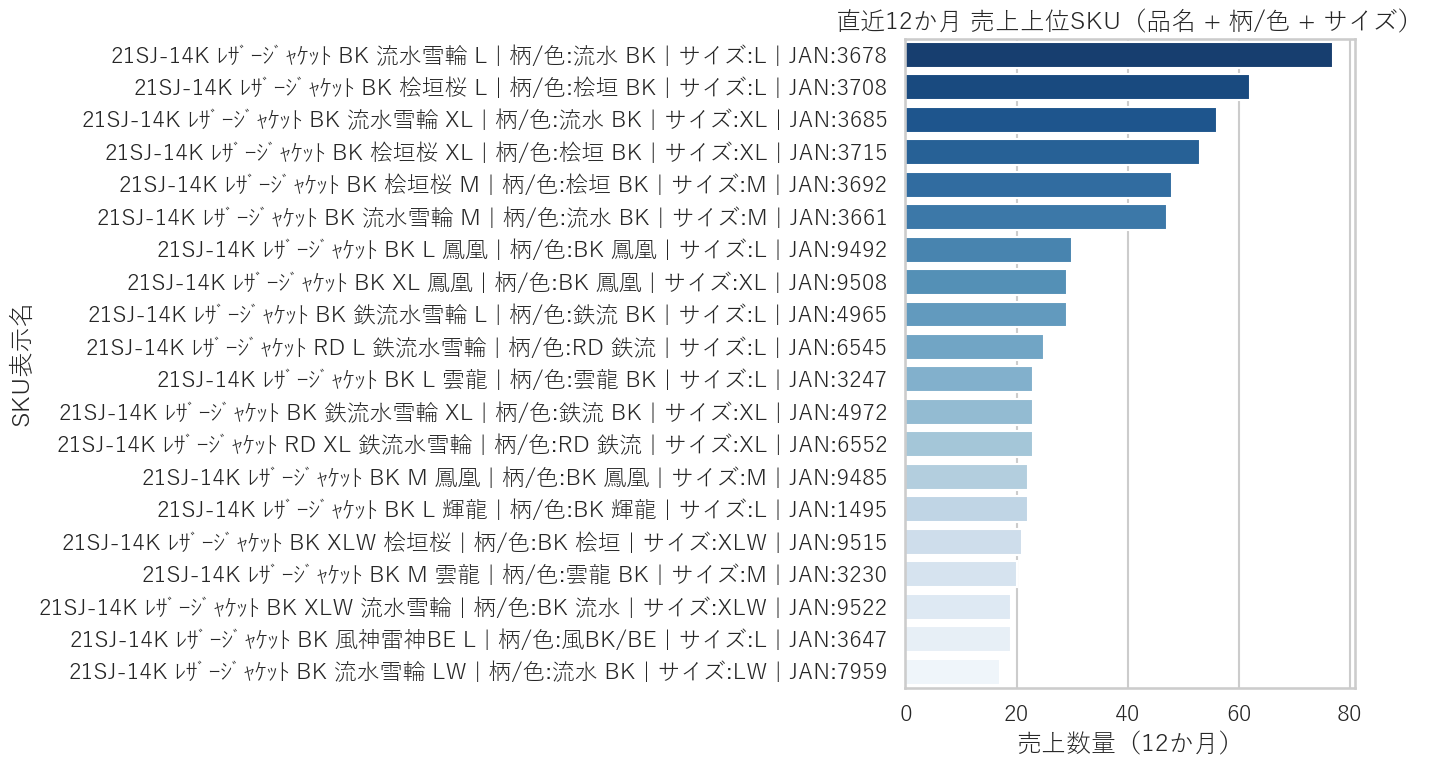

In [6]:
analysis_end = sales['sales_date'].max()
start_12m = analysis_end - pd.DateOffset(months=12)
start_3m = analysis_end - pd.DateOffset(months=3)

sales_12m = (
    sales[sales['sales_date'] >= start_12m]
    .groupby('jan', as_index=False)['sales_qty'].sum()
    .rename(columns={'sales_qty': 'sales_12m'})
)
sales_3m = (
    sales[sales['sales_date'] >= start_3m]
    .groupby('jan', as_index=False)['sales_qty'].sum()
    .rename(columns={'sales_qty': 'sales_3m'})
)
sales_all = (
    sales.groupby('jan', as_index=False)['sales_qty'].sum()
    .rename(columns={'sales_qty': 'sales_total'})
)

demand = sales_all.merge(sales_12m, on='jan', how='left').merge(sales_3m, on='jan', how='left').fillna(0)
demand = demand.merge(master[['jan', 'sku_label']], on='jan', how='left')

# 品名中心で上位表示
top_demand = demand.sort_values('sales_12m', ascending=False).head(20)
plt.figure(figsize=(14, 8))
sns.barplot(data=top_demand, x='sales_12m', y='sku_label', palette='Blues_r')
plt.title('直近12か月 売上上位SKU（品名 + 柄/色 + サイズ）')
plt.xlabel('売上数量（12か月）')
plt.ylabel('SKU表示名')
plt.tight_layout()
plt.show()

## Step 3. 供給不足（発注残）を見る

供給側は次を確認します。
- `open_qty_total`: まだ埋まっていない発注残
- `unreceived_qty`: その中でも未入荷の残

未入荷比率が高いSKUは、実務上のリスクが高いです。

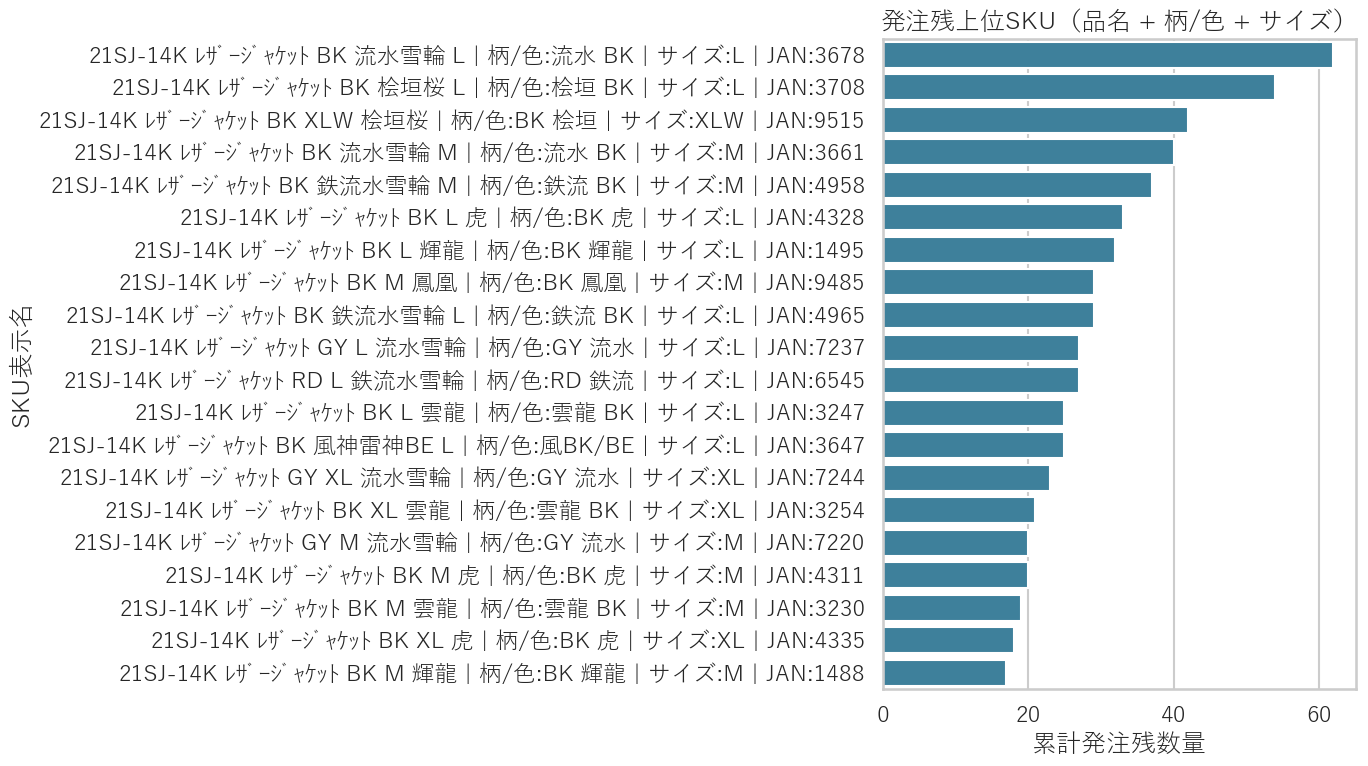

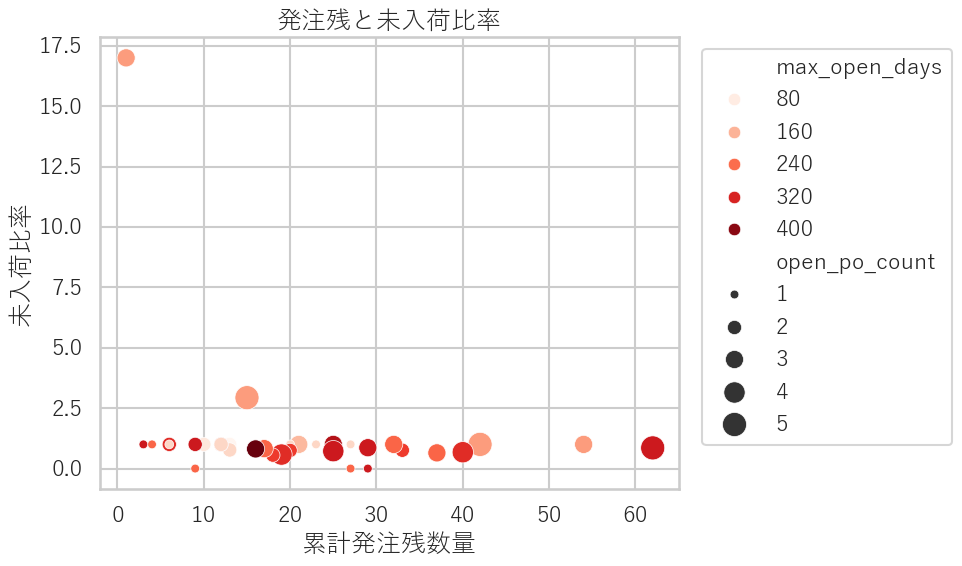

In [17]:
open_plot = open_jan.copy()
open_plot['unreceived_ratio'] = np.where(
    open_plot['open_qty_total'] > 0,
    open_plot['unreceived_qty'] / open_plot['open_qty_total'],
    0
)

# 発注残上位（品名中心）
top_open = open_plot.sort_values('open_qty_total', ascending=False).head(20)
plt.figure(figsize=(14, 8))
sns.barplot(data=top_open, x='open_qty_total', y='sku_label', color='#2E86AB')
plt.title('発注残上位SKU（品名 + 柄/色 + サイズ）')
plt.xlabel('累計発注残数量')
plt.ylabel('SKU表示名')
plt.tight_layout()
plt.show()

# 発注残と未入荷比率の関係
plt.figure(figsize=(10, 6))
sc_df = open_plot[open_plot['open_qty_total'] > 0].copy()
sns.scatterplot(
    data=sc_df,
    x='open_qty_total',
    y='unreceived_ratio',
    size='open_po_count',
    hue='max_open_days',
    palette='Reds',
    sizes=(40, 300)
)
plt.title('発注残と未入荷比率')
plt.xlabel('累計発注残数量')
plt.ylabel('未入荷比率')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Step 4. 欠品履歴（在庫ゼロ日数）を見る

欠品日数が長いSKUは、売り逃しリスクが高い可能性があります。
ここではSKUごとに欠品日数を集約します。


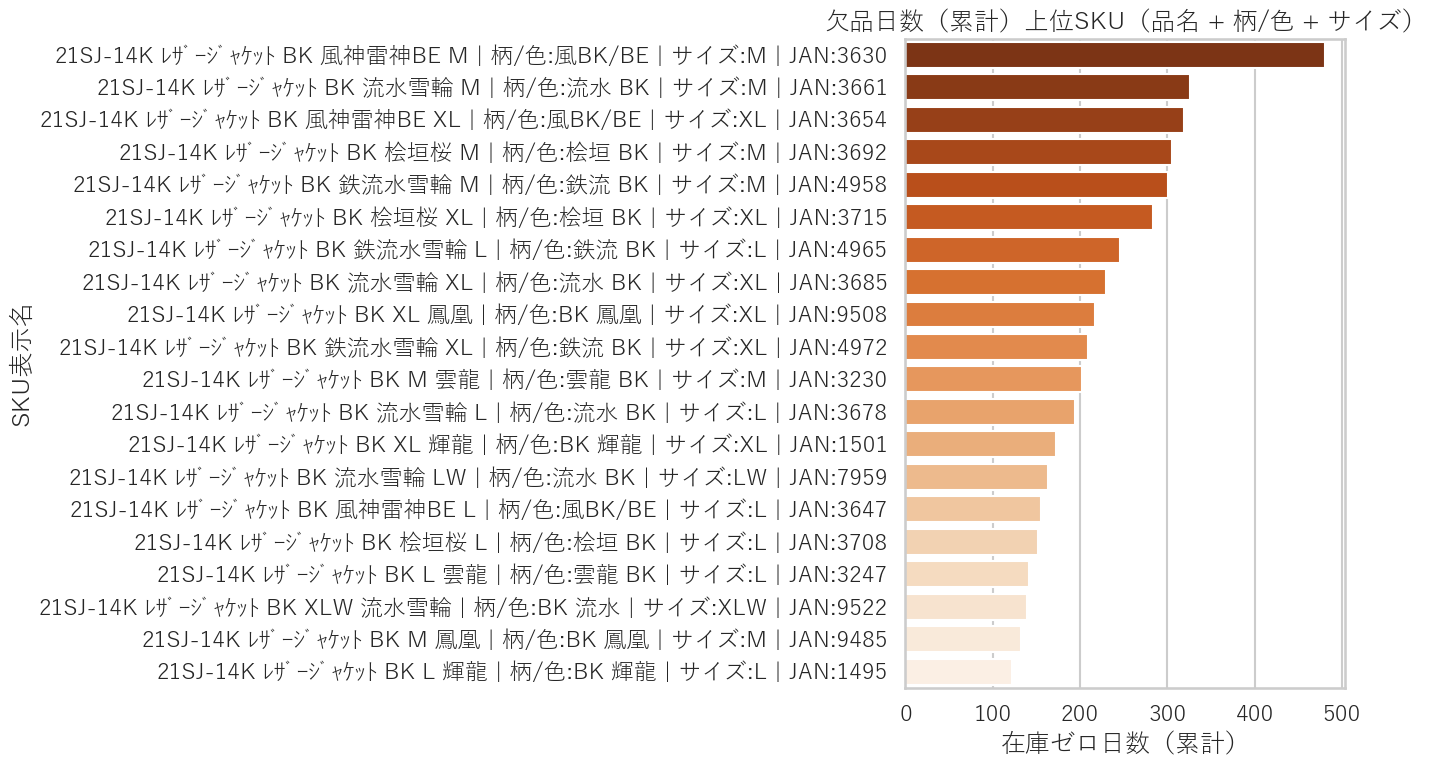

In [9]:
stockout_jan = (
    stockout.groupby('jan', as_index=False)
    .agg(
        stockout_days_total=('stockout_days', 'sum'),
        stockout_days_max=('stockout_days', 'max'),
        stockout_events=('stockout_days', 'count')
    )
)
stockout_jan = stockout_jan.merge(master[['jan', 'sku_label']], on='jan', how='left')

# 欠品日数上位（品名中心）
top_so = stockout_jan.sort_values('stockout_days_total', ascending=False).head(20)
plt.figure(figsize=(14, 8))
sns.barplot(data=top_so, x='stockout_days_total', y='sku_label', palette='Oranges_r')
plt.title('欠品日数（累計）上位SKU（品名 + 柄/色 + サイズ）')
plt.xlabel('在庫ゼロ日数（累計）')
plt.ylabel('SKU表示名')
plt.tight_layout()
plt.show()

## Step 4.5. 現在在庫を加えた見方（重要）

**今の在庫**を入れないと優先順位がブレます。

ここではSKUごとに最新取引日の在庫数を取得し、
- `current_stock_qty`: 現在在庫
- `inventory_pressure = max(0, sales_3m - current_stock_qty)`
を作ります。

`inventory_pressure` が大きいSKUほど、足元の在庫が需要に対して不足している可能性が高いです。


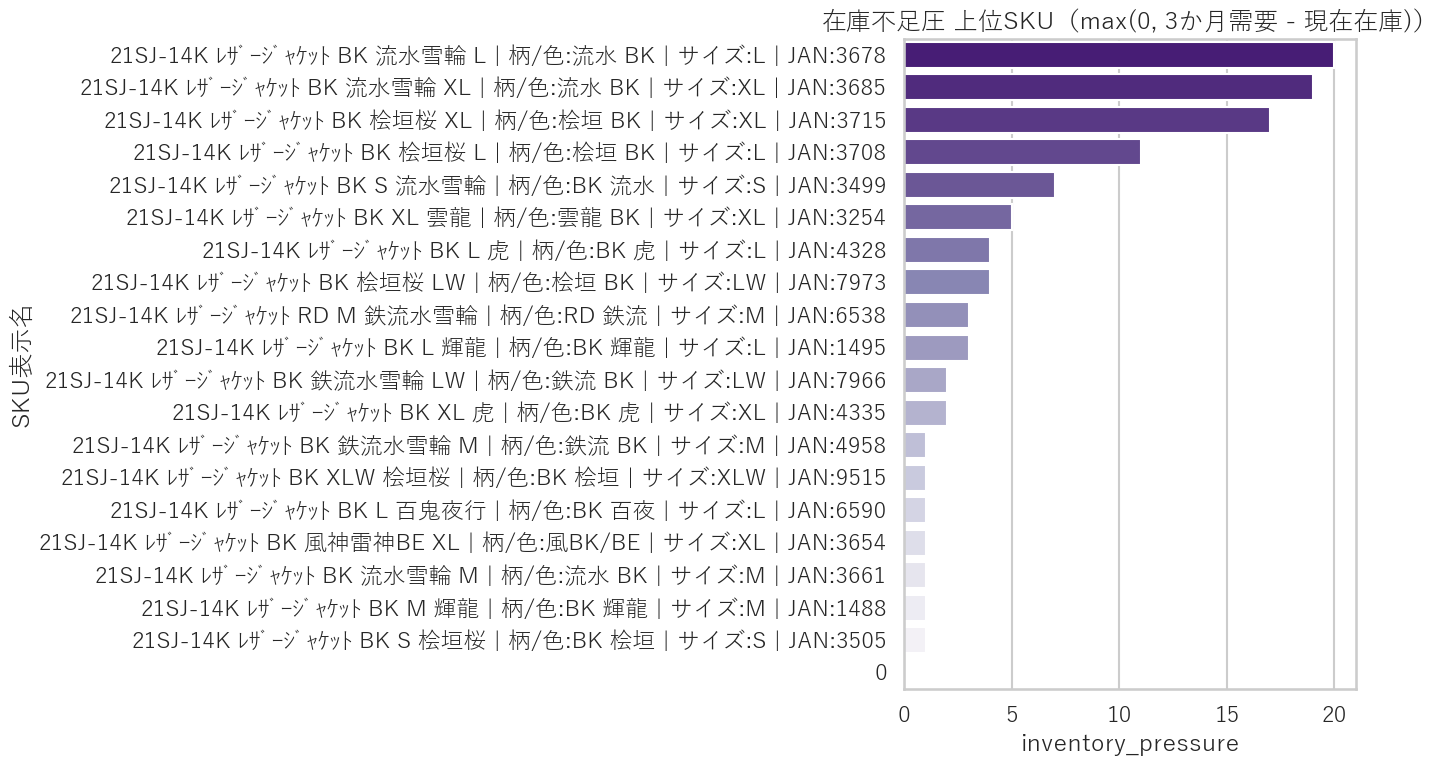

,sku_label,sales_3m,current_stock_qty,inventory_pressure
7,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 L | 柄/色:流水 BK | サイ...,23.0,3.0,20.0
8,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 XL | 柄/色:流水 BK | サ...,19.0,0.0,19.0
11,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 XL | 柄/色:桧垣 BK | サイ...,17.0,0.0,17.0
10,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 L | 柄/色:桧垣 BK | サイズ...,11.0,0.0,11.0
48,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK S 流水雪輪 | 柄/色:BK 流水 | サイ...,7.0,0.0,7.0
23,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XL 雲龍 | 柄/色:雲龍 BK | サイズ...,5.0,0.0,5.0
51,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 虎 | 柄/色:BK 虎 | サイズ:L ...,7.0,3.0,4.0
20,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 LW | 柄/色:桧垣 BK | サイ...,6.0,2.0,4.0
27,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ RD M 鉄流水雪輪 | 柄/色:RD 鉄流 | サ...,5.0,2.0,3.0
46,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 輝龍 | 柄/色:BK 輝龍 | サイズ:...,4.0,1.0,3.0


In [10]:
# SKU別の最新在庫を作成
# 同一JANで複数行あるため、取引日でソートして最後の行を現在在庫とみなします。
ledger_sorted = stock_ledger.sort_values(['jan', 'txn_date']).copy()
current_stock = (
    ledger_sorted
    .groupby('jan', as_index=False)
    .tail(1)[['jan', 'txn_date', 'stock_qty']]
    .rename(columns={'txn_date': 'latest_txn_date', 'stock_qty': 'current_stock_qty'})
)

# 需要（3か月）との比較
stock_need = (
    demand[['jan', 'sales_3m', 'sales_12m']]
    .merge(current_stock[['jan', 'current_stock_qty']], on='jan', how='left')
    .merge(master[['jan', 'sku_label']], on='jan', how='left')
    .fillna(0)
)
stock_need['inventory_pressure'] = (stock_need['sales_3m'] - stock_need['current_stock_qty']).clip(lower=0)

# 在庫不足圧の上位を可視化（品名 + 柄/色 + サイズ）
top_inv = stock_need.sort_values('inventory_pressure', ascending=False).head(20)
plt.figure(figsize=(14, 8))
sns.barplot(data=top_inv, x='inventory_pressure', y='sku_label', palette='Purples_r')
plt.title('在庫不足圧 上位SKU（max(0, 3か月需要 - 現在在庫)）')
plt.xlabel('inventory_pressure')
plt.ylabel('SKU表示名')
plt.tight_layout()
plt.show()

stock_need[['sku_label', 'sales_3m', 'current_stock_qty', 'inventory_pressure']].sort_values('inventory_pressure', ascending=False).head(20)

## Step 5. このノートで使う統計式（数学記法）

ここでは、優先度計算に使う式を数学の書き方で整理します。

### 記号の定義
- \(i\): SKUの添字
- \(k\): 発注（発注No）の添字
- \(P_{ik}\): SKU \(i\) の発注 \(k\) における発注数量
- \(R_{ik}\): SKU \(i\) の発注 \(k\) における入荷数量
- \(S_i^{(3m)}\): SKU \(i\) の直近3か月売上
- \(C_i\): SKU \(i\) の現在在庫
- \(\varepsilon\): ゼロ割回避用の微小値

### 1. 発注残（累計）
\[
O_i = \sum_k (P_{ik} - R_{ik})
\]

### 2. 未入荷残（未入荷発注のみ）
\[
U_i = \sum_{k \in \mathcal{N}_i} (P_{ik} - R_{ik})
\]
- \(\mathcal{N}_i\) は「未入荷」と判定された発注集合。

### 3. 未入荷比率
\[
r_i = \frac{U_i}{\max(O_i, \varepsilon)}
\]

### 4. 在庫不足圧
\[
I_i = \max\left(0,\ S_i^{(3m)} - C_i\right)
\]

### 5. Min-Max正規化
\[
\tilde{x}_i = \frac{x_i - \min_j x_j}{\max_j x_j - \min_j x_j}
\]
- ただし \(\max_j x_j = \min_j x_j\) のときは \(\tilde{x}_i = 0\)。

### 6. 優先度スコア（このノートの実装）
\[
\mathrm{Score}_i =
0.30\,\tilde{D}_i +
0.30\,\tilde{N}_i +
0.20\,\tilde{S}_i +
0.10\,\tilde{W}_i +
0.10\,\tilde{I}_i
\]
- \(\tilde{D}_i\): 需要スコア（12か月売上の正規化）
- \(\tilde{N}_i\): 不足スコア（発注残の正規化）
- \(\tilde{S}_i\): 欠品スコア（在庫ゼロ日数の正規化）
- \(\tilde{W}_i\): 滞留スコア（最大残あり経過日数の正規化）
- \(\tilde{I}_i\): 在庫不足圧スコア（正規化）

### 7. 月キャパ配分（比例配分）
\[
q_i^{(0)} = C \cdot \frac{w_i}{\sum_j w_j}
\]
\[
q_i = \min\left(\lfloor q_i^{(0)} \rfloor,\ O_i^+\right),
\quad O_i^+ = \max(O_i, 0)
\]
- 実装上の \(w_i\) は `priority_score`（微小値を加えてゼロ割回避）。

In [11]:
# 統計量を実データで確認（在庫条件を追加）
# JANで結合して、在庫統計がSKU単位で正しく対応するようにします。
stats_df = open_jan[['jan', 'po_qty_total', 'recv_qty_total', 'open_qty_total', 'unreceived_qty', 'max_open_days']].copy()

# 現在在庫を追加
stats_df = stats_df.merge(current_stock[['jan', 'current_stock_qty']], on='jan', how='left')
stats_df['current_stock_qty'] = stats_df['current_stock_qty'].fillna(0)

desc = stats_df[['po_qty_total', 'recv_qty_total', 'open_qty_total', 'unreceived_qty', 'max_open_days', 'current_stock_qty']]    .describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc.columns = ['件数', '平均', '標準偏差', '最小', '第1四分位', '中央値', '第3四分位', '最大']
desc

,件数,平均,標準偏差,最小,第1四分位,中央値,第3四分位,最大
po_qty_total,53.0,70.188679,78.959594,2.0,18.0,49.0,88.0,340.0
recv_qty_total,53.0,56.301887,71.261594,0.0,7.0,28.0,67.0,286.0
open_qty_total,53.0,13.886792,15.251306,-3.0,0.0,10.0,23.0,62.0
unreceived_qty,53.0,12.509434,13.995360,0.0,0.0,10.0,20.0,54.0
max_open_days,53.0,168.528302,137.390600,0.0,0.0,186.0,308.0,427.0
current_stock_qty,53.0,4.226415,6.550518,0.0,0.0,2.0,6.0,34.0


## Step 5. 優先度スコアを作る（考え方）

### なぜスコア化するのか
実務では指標が複数あります。
- 売上が高い
- 発注残が多い
- 欠品日数が長い
- 残の滞留日数が長い

このままだと比較しづらいので、各指標を0〜1に正規化して重み付け合算します。

### 今回の重み（初期案）
- 需要（直近12か月売上）: 35%
- 不足（発注残）: 35%
- 欠品履歴（在庫ゼロ日数）: 20%
- 滞留（日数）: 10%

> この重みは後で運用に合わせて調整可能です。

In [12]:
prio = (
    open_jan
    .merge(demand[['jan', 'sales_total', 'sales_12m', 'sales_3m']], on='jan', how='left')
    .merge(stockout_jan[['jan', 'stockout_days_total', 'stockout_days_max', 'stockout_events']], on='jan', how='left')
    .merge(current_stock[['jan', 'current_stock_qty']], on='jan', how='left')
)

prio[['sales_total', 'sales_12m', 'sales_3m', 'stockout_days_total', 'stockout_days_max', 'stockout_events', 'current_stock_qty']] =     prio[['sales_total', 'sales_12m', 'sales_3m', 'stockout_days_total', 'stockout_days_max', 'stockout_events', 'current_stock_qty']].fillna(0)

# 過入荷（マイナス残）は配分対象から外すため、0で打ち止め
prio['open_qty_pos'] = prio['open_qty_total'].clip(lower=0)

# 在庫不足圧（追加）
prio['inventory_pressure'] = (prio['sales_3m'] - prio['current_stock_qty']).clip(lower=0)

# 0〜1正規化

def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

prio['score_need'] = minmax(prio['open_qty_pos'])
prio['score_demand'] = minmax(prio['sales_12m'])
prio['score_stockout'] = minmax(prio['stockout_days_total'])
prio['score_wait'] = minmax(prio['max_open_days'])
prio['score_inventory'] = minmax(prio['inventory_pressure'])

# 在庫条件を組み込んだ重み
prio['priority_score'] = (
    0.30 * prio['score_demand'] +
    0.30 * prio['score_need'] +
    0.20 * prio['score_stockout'] +
    0.10 * prio['score_wait'] +
    0.10 * prio['score_inventory']
)

prio['is_target'] = prio['open_qty_pos'] > 0

prio_top = prio.sort_values('priority_score', ascending=False)[[
    'sku_label', 'sales_12m', 'sales_3m', 'current_stock_qty', 'inventory_pressure',
    'open_qty_pos', 'unreceived_qty', 'stockout_days_total', 'max_open_days',
    'priority_score', 'is_target'
]].head(20)
prio_top

,sku_label,sales_12m,sales_3m,current_stock_qty,inventory_pressure,open_qty_pos,unreceived_qty,stockout_days_total,max_open_days,priority_score,is_target
0,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 L | 柄/色:流水 BK | サイ...,77.0,23.0,3.0,20.0,62.0,53.0,194.0,333.0,0.858819,True
1,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 L | 柄/色:桧垣 BK | サイズ...,62.0,11.0,0.0,11.0,54.0,54.0,152.0,186.0,0.664742,True
3,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 M | 柄/色:流水 BK | サイ...,47.0,9.0,8.0,1.0,40.0,27.0,326.0,308.0,0.589630,True
21,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 XL | 柄/色:桧垣 BK | サイ...,53.0,17.0,0.0,17.0,15.0,44.0,283.0,186.0,0.525551,True
52,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 XL | 柄/色:流水 BK | サ...,56.0,19.0,0.0,19.0,0.0,14.0,230.0,333.0,0.487001,False
8,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 L | 柄/色:鉄流 BK | サ...,29.0,9.0,15.0,0.0,29.0,0.0,246.0,333.0,0.433796,True
4,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 M | 柄/色:鉄流 BK | サ...,16.0,1.0,0.0,1.0,37.0,24.0,301.0,248.0,0.429866,True
24,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 風神雷神BE M | 柄/色:風BK/BE |...,8.0,2.0,6.0,0.0,12.0,12.0,480.0,333.0,0.367219,True
6,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 輝龍 | 柄/色:BK 輝龍 | サイズ:...,22.0,4.0,1.0,3.0,32.0,32.0,122.0,248.0,0.364466,True
34,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 M | 柄/色:桧垣 BK | サイズ...,48.0,15.0,16.0,0.0,1.0,17.0,305.0,186.0,0.362495,True


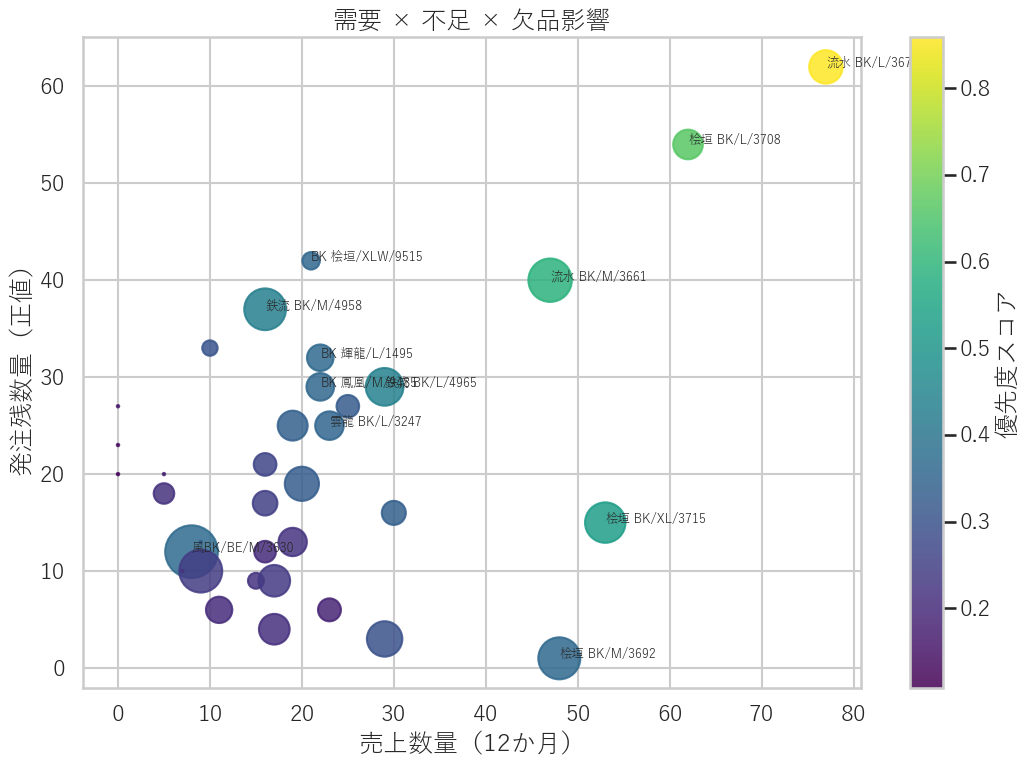

In [13]:
# 優先度の俯瞰図
# x: 需要（12か月売上）
# y: 不足（発注残）
# 色: 優先度スコア
# 点サイズ: 欠品日数
plot_prio = prio[prio['is_target']].copy()

plt.figure(figsize=(11, 8))
sc = plt.scatter(
    plot_prio['sales_12m'],
    plot_prio['open_qty_pos'],
    c=plot_prio['priority_score'],
    s=plot_prio['stockout_days_total'].clip(lower=1) * 3,
    cmap='viridis',
    alpha=0.85
)

for _, r in plot_prio.sort_values('priority_score', ascending=False).head(12).iterrows():
    short_label = f"{str(r['color'])}/{str(r['size'])}/{str(r['jan'])[-4:]}"
    plt.text(r['sales_12m'], r['open_qty_pos'], short_label, fontsize=9)

cbar = plt.colorbar(sc)
cbar.set_label('優先度スコア')
plt.title('需要 × 不足 × 欠品影響')
plt.xlabel('売上数量（12か月）')
plt.ylabel('発注残数量（正値）')
plt.tight_layout()
plt.show()

## Step 6. 月200着制約で配分シミュレーション

### 配分ロジック
1. 優先度スコアに比例して暫定配分
2. SKUごとの上限を「発注残数量」に制限
3. 端数や余りは高優先SKUから1着ずつ再配分

これで「優先度に沿う」かつ「過剰配分しない」案を作れます。


In [ ]:
capacity = 200

alloc = prio[prio['is_target']].copy().sort_values('priority_score', ascending=False).reset_index(drop=True)
alloc['weight'] = alloc['priority_score'] + 1e-6  # ゼロ割・ゼロ配分偏り回避
alloc['need_cap'] = alloc['open_qty_pos']

# 第1段階: 比例配分
alloc['alloc_qty'] = capacity * alloc['weight'] / alloc['weight'].sum()
alloc['alloc_qty'] = np.floor(alloc[['alloc_qty', 'need_cap']].min(axis=1))

# 第2段階: 余りを再配分
remaining = int(capacity - alloc['alloc_qty'].sum())
if remaining > 0:
    for _ in range(remaining):
        cands = alloc[alloc['alloc_qty'] < alloc['need_cap']].sort_values('priority_score', ascending=False)
        if len(cands) == 0:
            break
        idx = cands.index[0]
        alloc.loc[idx, 'alloc_qty'] += 1

alloc['alloc_qty'] = alloc['alloc_qty'].astype(int)
alloc['remain_after_alloc'] = alloc['need_cap'] - alloc['alloc_qty']

alloc_plan = alloc[[
    'sku_label', 'priority_score', 'sales_12m', 'need_cap',
    'alloc_qty', 'remain_after_alloc', 'unreceived_qty', 'stockout_days_total'
]].rename(columns={'need_cap': 'open_qty'})

alloc_plan.sort_values(['alloc_qty', 'priority_score'], ascending=[False, False]).head(30)

,sku_label,priority_score,sales_12m,open_qty,alloc_qty,remain_after_alloc,unreceived_qty,stockout_days_total
0,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 L | 柄/色:流水 BK | サイ...,0.858819,77.0,62.0,43,19.0,53.0,194.0
1,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 L | 柄/色:桧垣 BK | サイズ...,0.664742,62.0,54.0,12,42.0,54.0,152.0
2,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 流水雪輪 M | 柄/色:流水 BK | サイ...,0.589630,47.0,40.0,10,30.0,27.0,326.0
3,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 桧垣桜 XL | 柄/色:桧垣 BK | サイ...,0.525551,53.0,15.0,9,6.0,44.0,283.0
4,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 L | 柄/色:鉄流 BK | サ...,0.433796,29.0,29.0,7,22.0,0.0,246.0
5,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 鉄流水雪輪 M | 柄/色:鉄流 BK | サ...,0.429866,16.0,37.0,7,30.0,24.0,301.0
6,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK 風神雷神BE M | 柄/色:風BK/BE |...,0.367219,8.0,12.0,6,6.0,12.0,480.0
7,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK L 輝龍 | 柄/色:BK 輝龍 | サイズ:...,0.364466,22.0,32.0,6,26.0,32.0,122.0
9,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK M 鳳凰 | 柄/色:BK 鳳凰 | サイズ:...,0.359023,22.0,29.0,6,23.0,25.0,132.0
10,21SJ-14K ﾚｻﾞｰｼﾞｬｹｯﾄ BK XLW 桧垣桜 | 柄/色:BK 桧垣 | サ...,0.355687,21.0,42.0,6,36.0,42.0,53.0


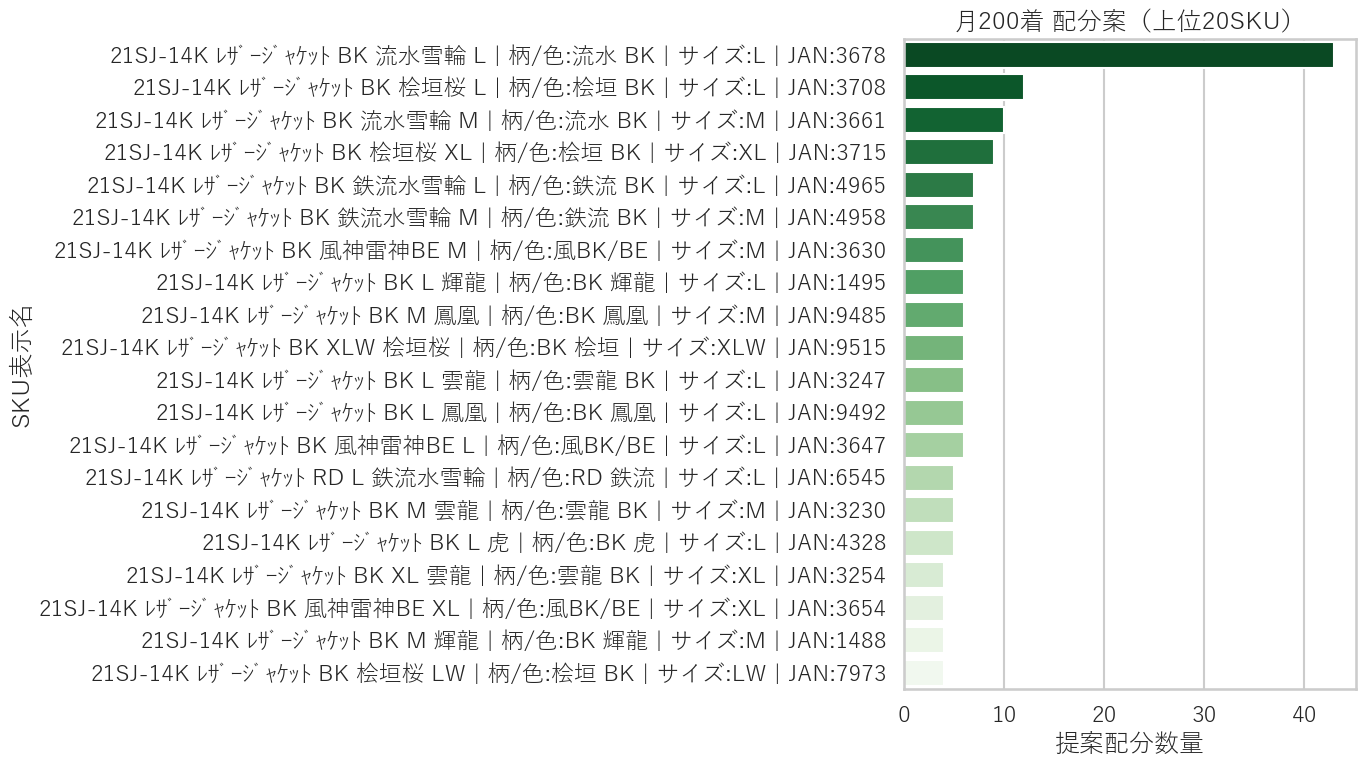

配分合計: 200 / 200
配分後の残余発注残 合計: 539.0


In [ ]:
# 配分結果を品名中心で可視化
vis = alloc_plan.sort_values('alloc_qty', ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(data=vis, x='alloc_qty', y='sku_label', palette='Greens_r')
plt.title('月200着 配分案（上位20SKU）')
plt.xlabel('提案配分数量')
plt.ylabel('SKU表示名')
plt.tight_layout()
plt.show()

print('配分合計:', int(alloc_plan['alloc_qty'].sum()), '/', capacity)
print('配分後の残余発注残 合計:', float(alloc_plan['remain_after_alloc'].sum()))

In [ ]:
# キャパシナリオ比較（100 / 150 / 200 / 250 / 300）
# 「200が妥当か？」を比較できるようにします。

def run_allocation(cap: int, frame: pd.DataFrame):
    tmp = frame[frame['is_target']].copy().sort_values('priority_score', ascending=False).reset_index(drop=True)
    tmp['weight'] = tmp['priority_score'] + 1e-6
    tmp['need'] = tmp['open_qty_pos']

    tmp['alloc'] = cap * tmp['weight'] / tmp['weight'].sum()
    tmp['alloc'] = np.floor(tmp[['alloc', 'need']].min(axis=1))

    rem = int(cap - tmp['alloc'].sum())
    if rem > 0:
        for _ in range(rem):
            cands = tmp[tmp['alloc'] < tmp['need']].sort_values('priority_score', ascending=False)
            if len(cands) == 0:
                break
            idx = cands.index[0]
            tmp.loc[idx, 'alloc'] += 1

    unresolved = float((tmp['need'] - tmp['alloc']).sum())
    return int(tmp['alloc'].sum()), unresolved

rows = []
for cap in [100, 150, 200, 250, 300]:
    used, unresolved = run_allocation(cap, prio)
    rows.append({'月間キャパ': cap, '配分実行数量': used, '配分後残余発注残': unresolved})

pd.DataFrame(rows)

,月間キャパ,配分実行数量,配分後残余発注残
0,100,100,639.0
1,150,150,589.0
2,200,200,539.0
3,250,250,489.0
4,300,300,439.0


## まとめ（実務での使い方）

### 読み取り方
- `priority_score` が高いSKUほど、月次配分で先に埋める
- `unreceived_qty` が大きいSKUは、発注先への納期確認を先行
- `inventory_pressure` が大きいSKUは、今の在庫では足元需要を支えにくい
- `open_qty_total < 0`（過入荷）のSKUは、新規発注を抑制

### 月次運用の推奨
1. 月初に最新CSVへ差し替え
2. このノートブックを上から実行
3. `alloc_plan` を工場生産計画の初期案にする
4. 月末に実績差分を見て、重み（30/30/20/10/10）を調整
